# Image Analysis with SSIM
This notebook contains the implementation of the `ml_model.py` script for analyzing image similarity.

In [29]:
# Import necessary libraries
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

import matplotlib.pyplot as plt

## Resize Image with Aspect Ratio
This function resizes an image while maintaining its aspect ratio.

In [30]:
def resize_with_aspect_ratio(image, width=None, height=None, inter=cv2.INTER_AREA):
    (h, w) = image.shape[:2]
    if width is None and height is None:
        return image
    if width is None:
        r = height / float(h)
        dim = (int(w * r), height)
    else:
        r = width / float(w)
        dim = (width, int(h * r))
    return cv2.resize(image, dim, interpolation=inter)

## Calculate SSIM
This function calculates the Structural Similarity Index (SSIM) between two images.

In [31]:
def calculate_ssim(img1, img2):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    # Compute SSIM between two images
    score, diff = ssim(img1_gray, img2_gray, full=True)
    diff = (diff * 255).astype('uint8')
    
    # Calculate percentage of difference using NumPy
    percentage_diff = np.round((1 - score) * 100, 2)
    return score, percentage_diff

## Analyze Images
This function analyzes the similarity between two images and returns the results.

In [32]:
def analyze_images(previous_image_path, current_image_path, category: str = 'default'):
    # Load images
    img1 = cv2.imread(previous_image_path)
    img2 = cv2.imread(current_image_path)

    # Resize images to the same dimensions
    img1 = resize_with_aspect_ratio(img1, width=500)
    img2 = resize_with_aspect_ratio(img2, width=500)

    # Calculate the similarity between the images
    similarity_score, percentage_difference = calculate_ssim(img1, img2)

    # Return analysis results
    return {
        'category': category,
        'similarity_score': f'{similarity_score:.2f}',
        'work_done_percentage': f'{100 - percentage_difference:.2f}%',
        'status': 'success',
        'message': f'Analysis complete for {category}.'
    }

## Pre-process and Outline Differences
This function pre-processes two images, extracts, and outlines the significant differences between them in blue on the second image.

In [33]:
def process_differences(img1, img2, ssim_img, resize_factor, win_size):
    # Apply Median Blur on the SSIM image
    ssim_img = cv2.medianBlur(ssim_img, win_size[0])

    # Apply thresholding with Otsu's method
    _, diff_binary = cv2.threshold(ssim_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find external contours for the areas that are different
    diff_contours, _ = cv2.findContours(diff_binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

    # Initialize an output image to outline differences
    outlined_img = img2.copy()

    # Process each contour
    for contour in diff_contours:
        area = cv2.contourArea(contour)
        if area > (6.7568 * img1.shape[1] - 11972.973) // resize_factor:
            cv2.drawContours(outlined_img, [contour], 0, (255, 0, 0), 2)  # Outline in blue

    # Return the image with differences outlined
    return outlined_img

## Process and Display Differences
This function processes two images to extract and outline the differences, then displays the images side by side.

In [34]:
import os
def process_and_display_differences(previous_image_path, current_image_path, resize_factor=1, win_size=(5, 5)):
    # Ensure output directory exists
    os.makedirs('temp_imgs', exist_ok=True)
    # Load images
    img1 = cv2.imread(previous_image_path)
    img2 = cv2.imread(current_image_path)

    # Convert images to grayscale
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Compute SSIM and difference image
    score, ssim_img = ssim(img1_gray, img2_gray, full=True)
    ssim_img = (ssim_img * 255).astype('uint8')

    # Process differences and outline them in blue
    outlined_img = process_differences(img1, img2, ssim_img, resize_factor, win_size)

    # Display the images side by side
    import matplotlib.pyplot as plt
    plt.figure(figsize=(18, 6))

    # Show the previous image
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Previous Image")
    plt.axis('off')

    # Show the outlined image
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(outlined_img, cv2.COLOR_BGR2RGB))
    plt.title("The Outlined Image")
    plt.axis('off')

    # Show the current image
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Current Image")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('temp_imgs/diff_display.png')
    plt.show()

    print(f"SSIM Score: {score:.2f}")

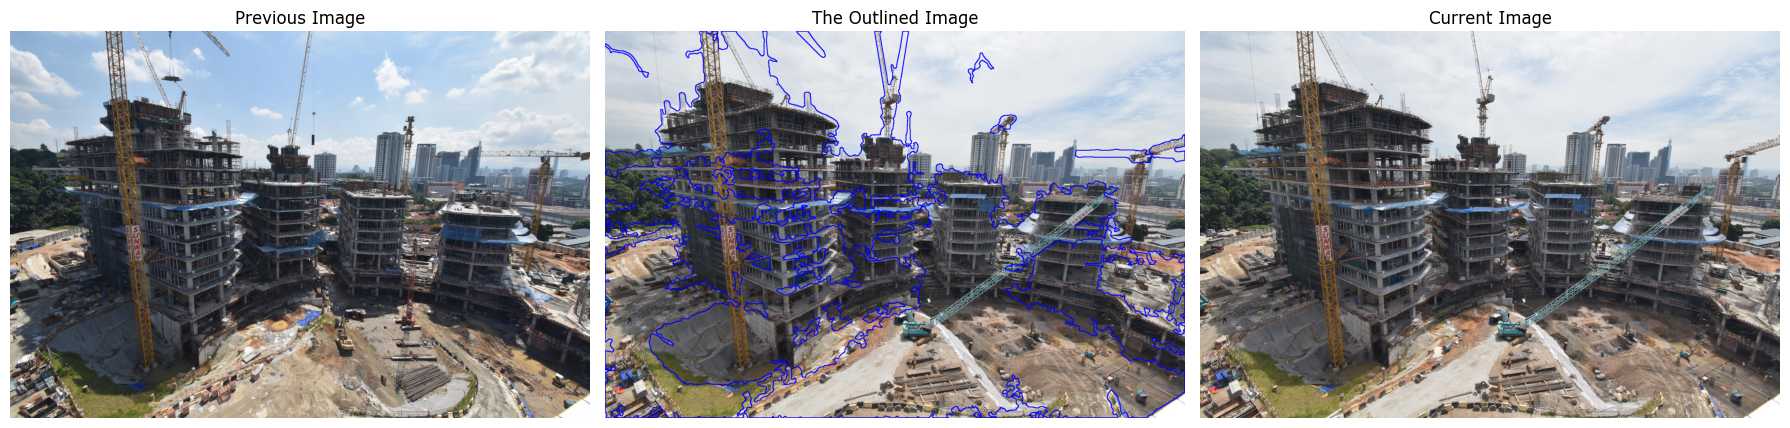

SSIM Score: 0.54


In [35]:
# git image width for 'TNB_3_1.jpg' and 'TNB_3_2.jpg' dynamically
# (Assuming the images are of the same size)
imageWidth = cv2.imread('TNB_3_1.jpg').shape[1]

winSize = int(0.0017 * imageWidth + 9.7568)
win_size = (winSize, winSize)

# Example usage
process_and_display_differences('TNB_3_1.jpg', 'TNB_3_2.jpg', resize_factor=1, win_size=win_size)

# Let's Implement the Full Image Alignment and Difference Detection Pipeline

We'll implement the following steps, inspired by Wong Tian Jie's pipeline:

1. **ResizeWithAspectRatio**: Resize images while maintaining aspect ratio.
2. **Image Alignment**: Use feature detection and matching (e.g., ORB/SURF) to align two images.
3. **Image Stitching**: Stitch aligned images and generate binary masks for each image's region.
4. **Overlap Extraction**: Extract the overlapping region between the two aligned images.
5. **SSIM Calculation**: Compute the SSIM on blurred grayscale (V channel) versions of the overlapped regions.
6. **Difference Detection**: Threshold the SSIM image, find contours of significant differences, and outline them.

We'll proceed step by step, implementing and testing each function in the notebook.

## Step 2: Image Alignment (ORB + Homography)

In [36]:
def align_images(img1, img2, max_features=500, good_match_percent=0.15):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(max_features)
    keypoints1, descriptors1 = orb.detectAndCompute(img1_gray, None)
    keypoints2, descriptors2 = orb.detectAndCompute(img2_gray, None)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = matcher.match(descriptors1, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)
    num_good_matches = int(len(matches) * good_match_percent)
    matches = matches[:num_good_matches]
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)
    for i, match in enumerate(matches):
        points1[i, :] = keypoints1[match.queryIdx].pt
        points2[i, :] = keypoints2[match.trainIdx].pt
    h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)
    # Calculate inlier percentage as a quality measure for the homography
    inlier_count = np.sum(mask)
    inlier_percentage = inlier_count / len(mask) * 100
    # Print alignment quality if percentage is below threshold
    if inlier_percentage < 40:
        print(f"Warning: Low alignment quality. Inliers: {inlier_percentage:.2f}%")
    height, width = img1.shape[:2]
    img2_aligned = cv2.warpPerspective(img2, h, (width, height))
    return img2_aligned, h

## Step 3: Overlap Mask and Extraction

In [37]:
def get_overlap_mask(img1, img2_aligned):
    mask1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) > 0
    mask2 = cv2.cvtColor(img2_aligned, cv2.COLOR_BGR2GRAY) > 0
    overlap = np.logical_and(mask1, mask2).astype(np.uint8) * 255
    return overlap

def extract_overlap(img, mask):
    return cv2.bitwise_and(img, img, mask=mask)

## Step 4: SSIM on Overlap

In [38]:
def compute_ssim_on_overlap(img1_overlap, img2_overlap, win_size=(11, 11)):
    img1_v = cv2.cvtColor(img1_overlap, cv2.COLOR_BGR2HSV)[:, :, 2]
    img2_v = cv2.cvtColor(img2_overlap, cv2.COLOR_BGR2HSV)[:, :, 2]
    img1_blur = cv2.blur(img1_v, win_size)
    img2_blur = cv2.blur(img2_v, win_size)
    score, ssim_img = ssim(img1_blur, img2_blur, full=True)
    ssim_img = (ssim_img * 255).astype('uint8')
    return score, ssim_img

## Step 5: Find and Draw Differences

In [39]:
def find_and_draw_differences(img2_overlap, ssim_img, image_width, resize_factor=1, win_size=(11, 11)):
    ssim_img = cv2.medianBlur(ssim_img, win_size[0])
    _, diff_binary = cv2.threshold(ssim_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(diff_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    outlined = img2_overlap.copy()
    for c in contours:
        area = cv2.contourArea(c)
        if area > (6.7568 * image_width - 11972.973) // resize_factor:
            cv2.drawContours(outlined, [c], 0, (0, 0, 255), 2)
    return outlined

## Step 6: Example Pipeline Usage

In [40]:
import os
def process_images(previous_image_path, current_image_path, resize_factor=1, win_size=(11, 11)):
    os.makedirs('temp_imgs', exist_ok=True)
    # Load images
    img1 = cv2.imread(previous_image_path)
    img2 = cv2.imread(current_image_path)
    
    # Display original images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Original Previous Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Original Current Image")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/originals.png')
    plt.show()

    # Resize images
    img1 = resize_with_aspect_ratio(img1, width=500)
    img2 = resize_with_aspect_ratio(img2, width=500)
    
    # Display resized images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Resized Previous Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Resized Current Image")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/resized.png')
    plt.show()

    # Align images
    img2_aligned, _ = align_images(img1, img2)
    
    # Display aligned image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Reference Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2_aligned, cv2.COLOR_BGR2RGB))
    plt.title("Aligned Current Image")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/aligned.png')
    plt.show()

    # Get overlap mask
    overlap_mask = get_overlap_mask(img1, img2_aligned)
    
    # Display overlap mask
    plt.figure(figsize=(8, 6))
    plt.imshow(overlap_mask, cmap='gray')
    plt.title("Overlap Mask")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/overlap_mask.png')
    plt.show()

    # Extract overlapping regions
    img1_overlap = extract_overlap(img1, overlap_mask)
    img2_overlap = extract_overlap(img2_aligned, overlap_mask)
    
    # Display overlapping regions
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1_overlap, cv2.COLOR_BGR2RGB))
    plt.title("Previous Image Overlap")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2_overlap, cv2.COLOR_BGR2RGB))
    plt.title("Current Image Overlap")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/overlap_regions.png')
    plt.show()

    # Compute SSIM on overlapping regions
    score, ssim_img = compute_ssim_on_overlap(img1_overlap, img2_overlap, win_size)
    
    # Display SSIM image
    plt.figure(figsize=(8, 6))
    plt.imshow(ssim_img, cmap='viridis')
    plt.title(f"SSIM Image (Score: {score:.4f})")
    plt.colorbar()
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/ssim_img.png')
    plt.show()

    # Find and draw differences
    outlined_img = find_and_draw_differences(img2_overlap, ssim_img, img1.shape[1], resize_factor, win_size)
    
    # Display final result
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1_overlap, cv2.COLOR_BGR2RGB))
    plt.title("Previous Overlap")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(outlined_img, cv2.COLOR_BGR2RGB))
    plt.title("Differences Outlined")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('temp_imgs/final_outlined.png')
    plt.show()

    return outlined_img, score

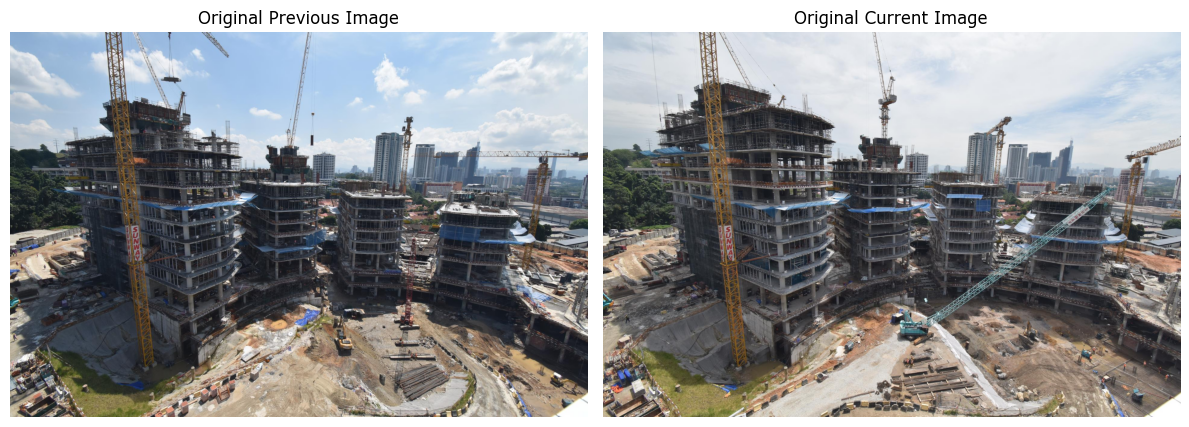

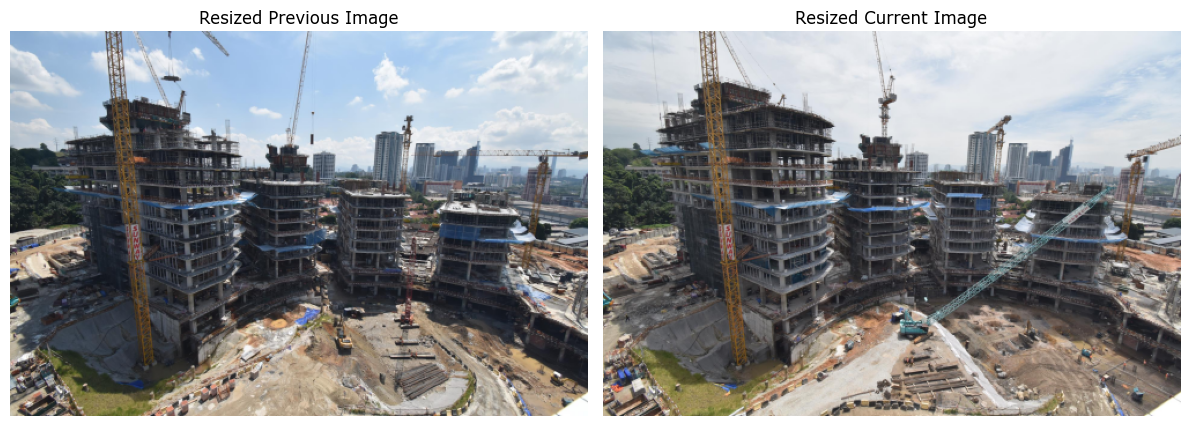

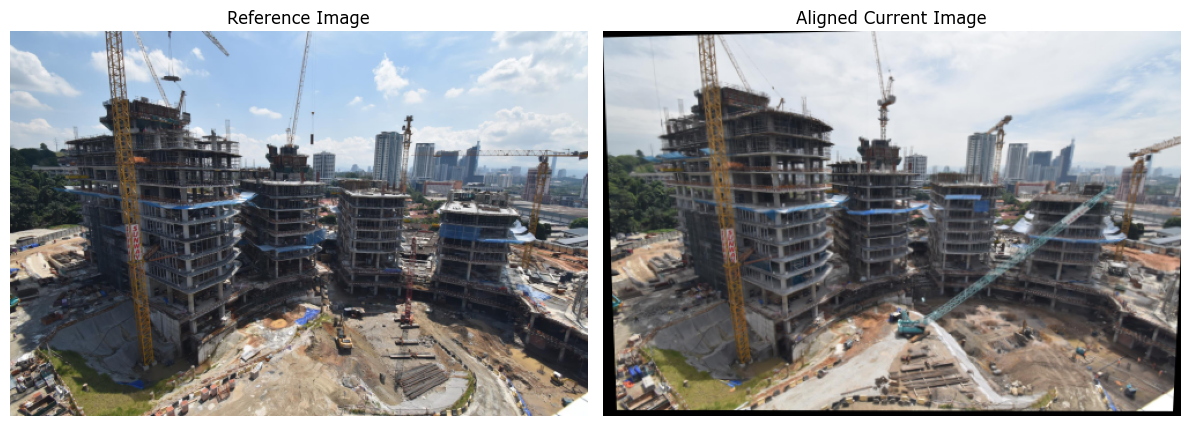

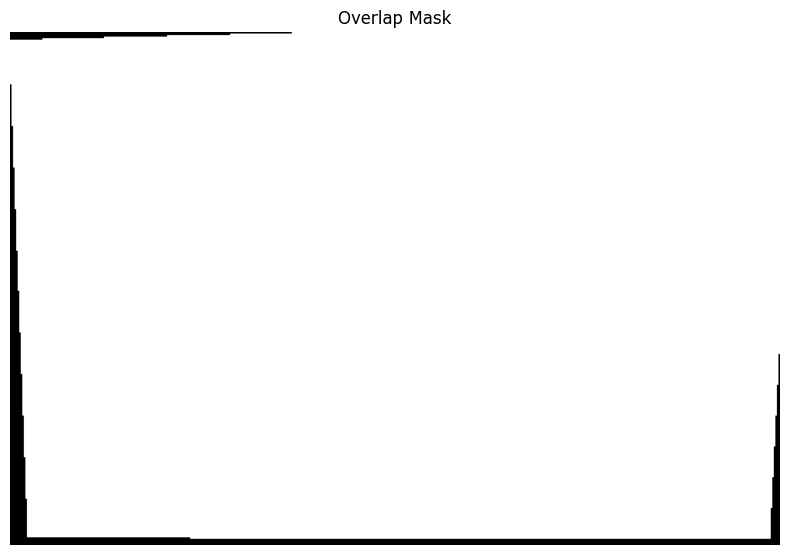

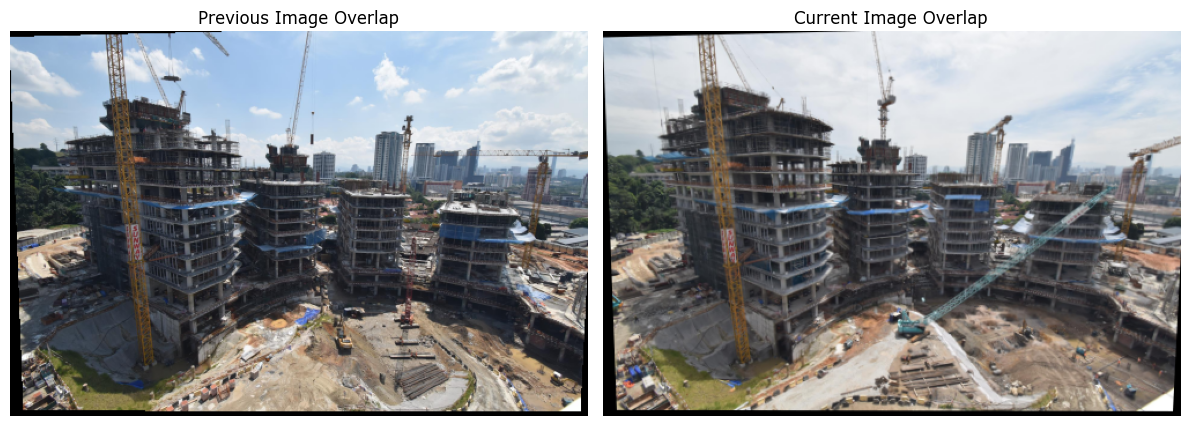

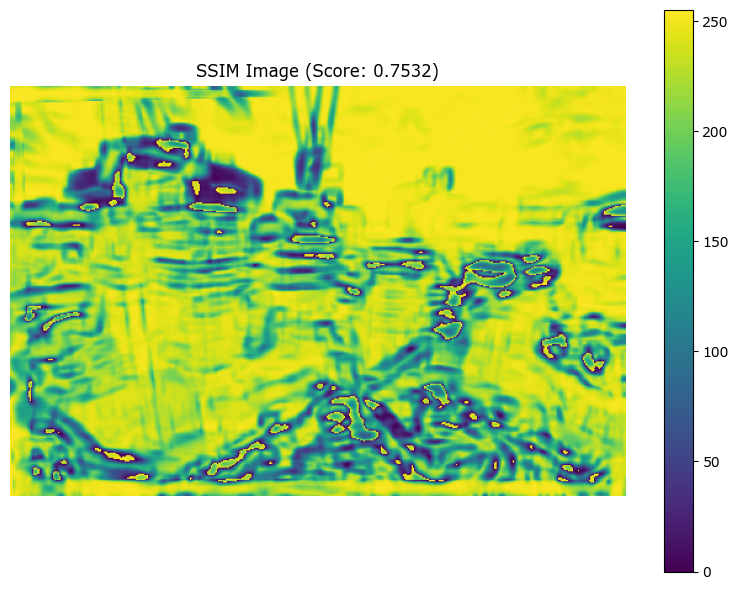

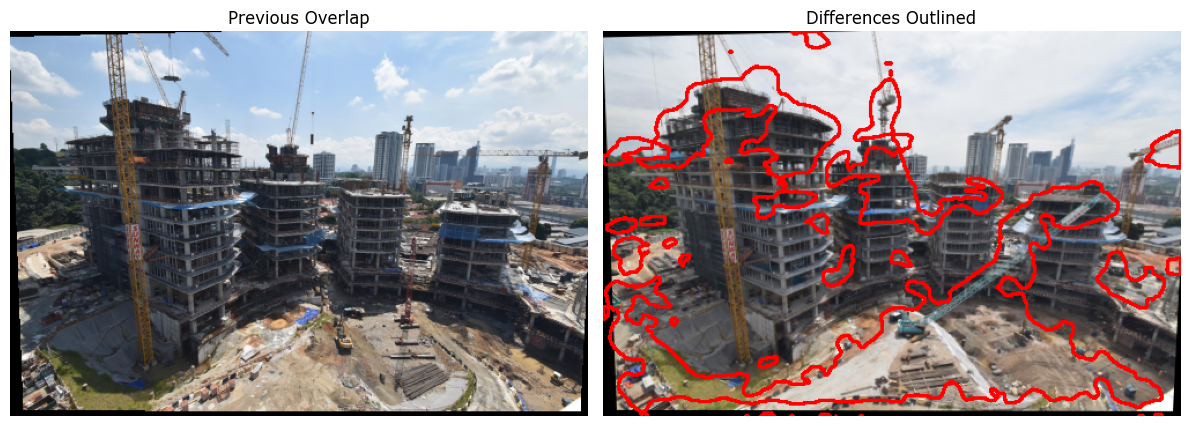

(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [236, 225, 211],
         [235, 224, 210],
         [234, 223, 209]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [235, 224, 210],
         [235, 224, 210],
         [234, 223, 209]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [235, 224, 210],
         [234, 223, 209],
         [233, 222, 208]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
  

In [41]:
winSize = int(0.0017 * imageWidth + 9.7568)
win_size = (winSize, winSize)

process_images('TNB_3_1.jpg', 'TNB_3_2.jpg', resize_factor=1, win_size=win_size)

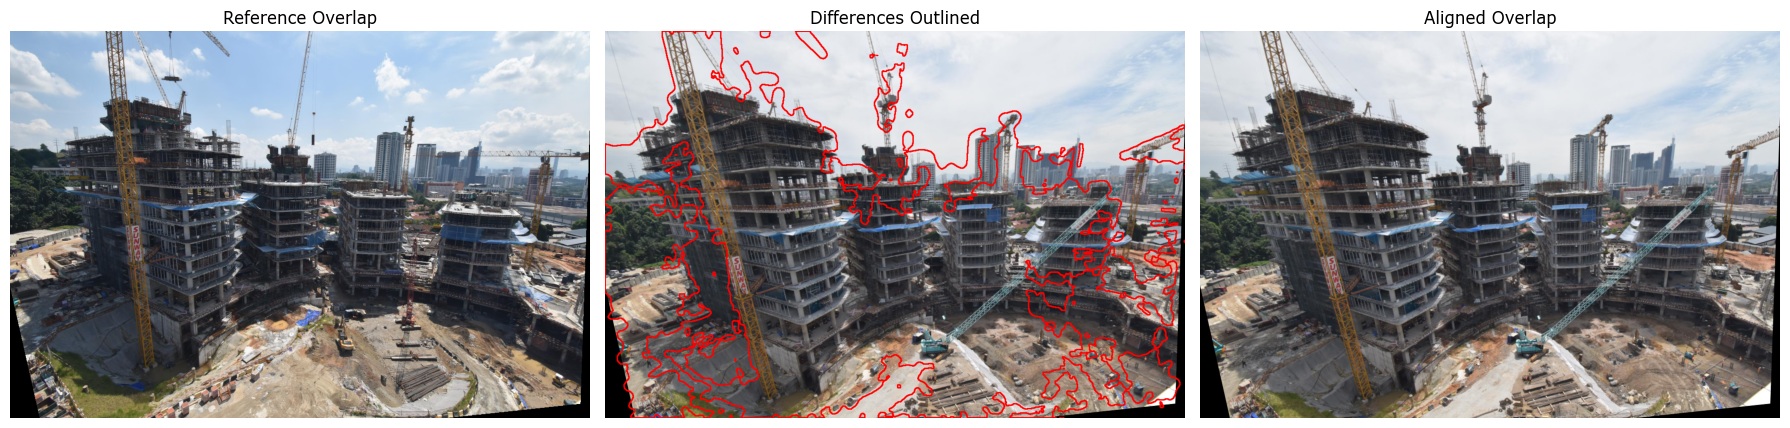

Mean SSIM: 0.613


In [42]:
# Example usage
import os
os.makedirs('temp_imgs', exist_ok=True)
img1 = cv2.imread("TNB_3_1.jpg")
img2 = cv2.imread("TNB_3_2.jpg")
img1 = resize_with_aspect_ratio(img1, width=1200)
img2 = resize_with_aspect_ratio(img2, width=1200)
img2_aligned, h = align_images(img1, img2)
overlap_mask = get_overlap_mask(img1, img2_aligned)
img1_overlap = extract_overlap(img1, overlap_mask)
img2_overlap = extract_overlap(img2_aligned, overlap_mask)
win_size = (13, 13)
score, ssim_img = compute_ssim_on_overlap(img1_overlap, img2_overlap, win_size)
outlined = find_and_draw_differences(img2_overlap, ssim_img, img1.shape[1], resize_factor=1, win_size=win_size)

# Display results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img1_overlap, cv2.COLOR_BGR2RGB))
plt.title("Reference Overlap")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(outlined, cv2.COLOR_BGR2RGB))
plt.title("Differences Outlined")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img2_overlap, cv2.COLOR_BGR2RGB))
plt.title("Aligned Overlap")
plt.axis("off")
plt.tight_layout()
plt.savefig('temp_imgs/example_usage.png')
plt.show()
print(f"Mean SSIM: {score:.3f}")

# All Output Images

The following images are saved in the `/temp_imgs/` folder during notebook execution:

- `diff_display.png`: Side-by-side comparison of previous, outlined, and current images.
- `originals.png`: Original previous and current images.
- `resized.png`: Resized previous and current images.
- `aligned.png`: Reference and aligned current image.
- `overlap_mask.png`: Overlap mask between aligned images.
- `overlap_regions.png`: Overlapping regions of previous and current images.
- `ssim_img.png`: SSIM image of the overlap region.
- `final_outlined.png`: Previous overlap and differences outlined.
- `example_usage.png`: Reference overlap, differences outlined, and aligned overlap.

# Step-by-Step Process for Image Alignment and Difference Detection Pipeline

1. **Import Libraries**: Load all necessary libraries such as OpenCV, NumPy, Matplotlib, and scikit-image's SSIM.
2. **Resize Images**: Use `resize_with_aspect_ratio` to resize both images to a common width while maintaining aspect ratio.
3. **Align Images**: Use ORB feature detection and homography (`align_images`) to align the current image to the previous image.
4. **Compute Overlap Mask**: Generate a binary mask representing the overlapping region between the aligned images (`get_overlap_mask`).
5. **Extract Overlapping Regions**: Use the overlap mask to extract the common regions from both images (`extract_overlap`).
6. **Compute SSIM on Overlap**: Convert the overlapping regions to the V channel, blur them, and compute the SSIM and SSIM image (`compute_ssim_on_overlap`).
7. **Find and Draw Differences**: Threshold the SSIM image, find contours of significant differences, and outline them on the aligned image (`find_and_draw_differences`).
8. **Display and Save Results**: Visualize each step and save output images for inspection.

This pipeline ensures robust comparison of two images, even if they are not perfectly aligned initially, and highlights significant differences in the overlapping region.